# Segmenting Lung X-ray Images with the Segment Anything Model
### Advanced Deep Learning 2022
Notebook written by [Jakob Ambsdorf](mailto:jaam@di.ku.dk).
Lung x-ray code originally written by Mathias Perslev. It has been changed slightly by Christian Igel and subsequently slightly updated [Stefan Sommer](mailto:sommer@di.ku.dk).
SAM related code (c) Meta Platforms, Inc. and affiliates.

We consider the data described in:
Bram van Ginneken, Mikkel B. Stegmann, Marco Loog. [Segmentation of anatomical structures in chest radiographs using supervised methods: a comparative study on a public database](https://doi.org/10.1016/j.media.2005.02.002). *Medical Image Analysis* 10(1): 19-40, 2006

## Object masks from prompts with SAM

The Segment Anything Model (SAM) predicts object masks given prompts that indicate the desired object. The model first converts the image into an image embedding that allows high quality masks to be efficiently produced from a prompt. 

The `SamPredictor` class provides an easy interface to the model for prompting the model. It allows the user to first set an image using the `set_image` method, which calculates the necessary image embeddings. Then, prompts can be provided via the `predict` method to efficiently predict masks from those prompts. The model can take as input both point and box prompts, as well as masks from the previous iteration of prediction.

## Environment Set-up

If running locally using jupyter, first install `segment_anything` in your environment using the [installation instructions](https://github.com/facebookresearch/segment-anything#installation) in the repository. If running from Google Colab, set `using_colab=True` below and run the cell. In Colab, be sure to select 'GPU' under 'Edit'->'Notebook Settings'->'Hardware accelerator'.

In [1]:
# using_colab = False

In [2]:
# if using_colab:
#     import torch
#     import torchvision
#     print("PyTorch version:", torch.__version__)
#     print("Torchvision version:", torchvision.__version__)
#     print("CUDA is available:", torch.cuda.is_available())
#     import sys
#     !{sys.executable} -m pip install opencv-python matplotlib
#     !{sys.executable} -m pip install 'git+https://github.com/facebookresearch/segment-anything.git'
    
#     !mkdir images
#     !wget -P images https://raw.githubusercontent.com/facebookresearch/segment-anything/main/notebooks/images/truck.jpg
#     !wget -P images https://raw.githubusercontent.com/facebookresearch/segment-anything/main/notebooks/images/groceries.jpg
        
#     !wget https://dl.fbaipublicfiles.com/segment_anything/sam_vit_h_4b8939.pth

## Set-up

Necessary imports and helper functions for displaying points, boxes, and masks.

In [10]:
import numpy as np
import torch
import matplotlib.pyplot as plt
import torchvision
import torchmetrics

/home/pkd916/miniconda3/envs/assignment3/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [4]:
print("PyTorch version:", torch.__version__)
print("Torchvision version:", torchvision.__version__)
print("CUDA is available:", torch.cuda.is_available())

PyTorch version: 2.5.1
Torchvision version: 0.20.1
CUDA is available: True


In [5]:
def show_mask(mask, ax, random_color=False):
    if random_color:
        color = np.concatenate([np.random.random(3), np.array([0.6])], axis=0)
    else:
        color = np.array([30/255, 144/255, 255/255, 0.6])
    h, w = mask.shape[-2:]
    mask_image = mask.reshape(h, w, 1) * color.reshape(1, 1, -1)
    ax.imshow(mask_image)
    
def show_points(coords, labels, ax, marker_size=375):
    pos_points = coords[labels==1]
    neg_points = coords[labels==0]
    ax.scatter(pos_points[:, 0], pos_points[:, 1], color='green', marker='*', s=marker_size, edgecolor='white', linewidth=1.25)
    ax.scatter(neg_points[:, 0], neg_points[:, 1], color='red', marker='*', s=marker_size, edgecolor='white', linewidth=1.25)   
    
def show_box(box, ax):
    x0, y0 = box[0], box[1]
    w, h = box[2] - box[0], box[3] - box[1]
    ax.add_patch(plt.Rectangle((x0, y0), w, h, edgecolor='green', facecolor=(0,0,0,0), lw=2))    


# Download model checkpoint
The checkpoint is 2.39GB, takes a few minutes for most bandwidths

In [6]:
# import urllib.request
# import os
# from tqdm import tqdm

# url = "https://dl.fbaipublicfiles.com/segment_anything/sam_vit_h_4b8939.pth"
# filename = "sam_vit_h_4b8939.pth"
# folder = "models"

# os.makedirs(folder, exist_ok=True)

# filepath = os.path.join(folder, filename)

# if not os.path.exists(filepath):
#     # Get the file size before downloading
#     file_size = int(urllib.request.urlopen(url).info().get("Content-Length", -1))

#     # Start the download with progress bar
#     with tqdm(unit="B", unit_scale=True, unit_divisor=1024, total=file_size, desc=filename, ncols=80) as pbar:
#         urllib.request.urlretrieve(url, filepath, reporthook=lambda b, bsize, t: pbar.update(bsize))
# else:
#     print("Checkpoint file already exists. Skipping download.")

In [7]:
# import sys
# sys.path.append("//mnt//c//Users//李楷政//Desktop//Assignment_3//images")
from segment_anything import sam_model_registry, SamPredictor

sam_checkpoint = "//mnt//f//Assignment_3//images//sam_vit_h_4b8939.pth"
model_type = "vit_h"

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

sam = sam_model_registry[model_type](checkpoint=sam_checkpoint)
sam.to(device=device)

predictor = SamPredictor(sam)

/mnt/f/Assignment_3/segment_anything/segment_anything/build_sam.py:105: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  state_dict = torch.load(f)


# Chest X-ray Dataset

In [9]:
import os
from torchvision.datasets.utils import download_url

In [9]:
# # Mount Google drive
# try:
#     from google.colab import drive
#     drive.mount('/content/gdrive/')
#     os.chdir('gdrive/MyDrive/ADL2022')
# except:
#     print('Google drive not mounted')

In [10]:
# If you are getting a download error, comment in the following lines:
# import ssl
# ssl._create_default_https_context = ssl._create_unverified_context

In [10]:
# Load database with chest X-rays with lung segmentations.
data_root='./datasets'
data_npz='lung_field_dataset.npz'
data_fn = os.path.join(data_root, "lung_field_dataset.npz")
force_download = False

if (not os.path.exists(data_fn)) or force_download:
    download_url("https://sid.erda.dk/share_redirect/gCTc6o3KAh", data_root, data_npz)
else:
    print('Using existing', data_fn)

Using existing ./datasets/lung_field_dataset.npz


In [11]:
def plot_image_with_segmentation(image, segmentation, ax=None):
    """
    Plots an image with overlayed segmentation mask
    
    Returns: plt.fig and ax objects
    """
    if ax is None:
        fig = plt.figure(figsize=(8, 8))
        ax = fig.add_subplot(111)
        ax.axis("off")
    
    ax.imshow(image.squeeze(), cmap="gray")
    mask = np.ma.masked_where(segmentation == 0, segmentation)
    ax.imshow(mask.squeeze(), cmap="Set1", alpha=0.5)
    return plt.gcf(), ax


def load_npz_dataset(path, keys=('x_train', 'y_train', 'x_val', 'y_val', 'x_test', 'y_test')):
    archive = np.load(path)
    return [archive.get(key) for key in keys]

In [12]:
def map_interval(image, from_min, from_max, to_min, to_max):
    """
    Map values from [from_min, from_max] to [to_min, to_max]
    """
    from_range = from_max - from_min
    to_range = to_max - to_min
    # scaled = np.array((image - from_min) / float(from_range), dtype=float)
    scaled = (image - from_min) / float(from_range)
    return to_min + (scaled * to_range)

In [13]:
# Load train/val/test data
x_train, y_train, x_val, y_val, x_test, y_test = load_npz_dataset(data_fn)

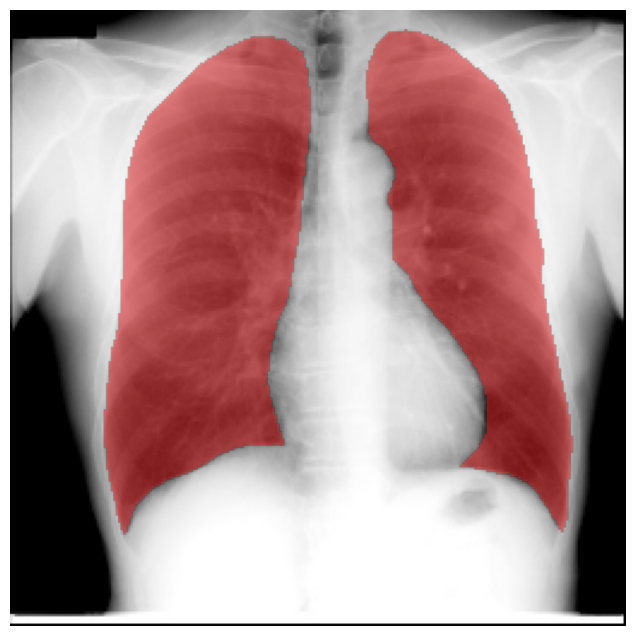

In [14]:

# TODO: 
# Bring images into the correct format for SAM:
# Image shape: (N, H, W, C=3)
# Mask shape: (N, H, W)
# Values: [0, 255] (uint8)

# YOUR CODE HERE


def xray_to_rgb(xray_images):
    """
    Convert X-ray images to RGB format by normalizing and scaling values using map_interval.

    Parameters:
        xray_images (numpy.ndarray): X-ray images with shape (N, H, W, 1) and arbitrary floating-point range.

    Returns:
        numpy.ndarray: RGB images of shape (N, H, W, 3) with values in [0, 255].
    """
    # Validate input
    if xray_images.ndim != 4 or xray_images.shape[-1] != 1:
        raise ValueError("Input X-ray images must have shape (N, H, W, 1)")

    # Squeeze the last dimension
    xray_images = np.squeeze(xray_images, axis=-1)

    # Find the min and max values
    min_val = np.min(xray_images)
    max_val = np.max(xray_images)

    # Normalize and scale using map_interval
    scaled_images = map_interval(xray_images, min_val, max_val, 0, 255).astype(np.uint8)

    # Stack into RGB format
    rgb_images = np.stack([scaled_images] * 3, axis=-1)

    return rgb_images


x_train = xray_to_rgb(x_train)
x_val = xray_to_rgb(x_val)
x_test = xray_to_rgb(x_test)

def remove_last_dimension(grayscale_images):
    """
    Convert grayscale images of shape (N, H, W, 1) to (N, H, W) by removing the last dimension.

    Parameters:
        grayscale_images (numpy.ndarray): Grayscale images of shape (N, H, W, 1).

    Returns:
        numpy.ndarray: Grayscale images of shape (N, H, W).
    """
    # Validate input
    if grayscale_images.ndim != 4 or grayscale_images.shape[-1] != 1:
        raise ValueError("Input images must have shape (N, H, W, 1)")

    # Remove the last dimension
    return np.squeeze(grayscale_images, axis=-1)

y_train = remove_last_dimension(y_train)
y_val = remove_last_dimension(y_val)
y_test = remove_last_dimension(y_test)
 

# your data should pass the following asserts
assert x_train.shape == (112, 256, 256, 3)
assert y_train.shape == (112, 256, 256)
assert x_val.shape == (12, 256, 256, 3)
assert y_val.shape == (12, 256, 256)
assert x_test.shape == (123, 256, 256, 3)
assert y_test.shape == (123, 256, 256)

assert x_train.dtype == y_train.dtype == np.uint8
assert np.min(x_train) == 0
assert np.max(x_train) == 255

# Plot an example
fig, ax = plot_image_with_segmentation(x_train[0], y_train[0])
plt.show()

# Single Example image

Let's try to run SAM on a single example image

In [18]:
example_img, example_mask = x_train[0], y_train[0]

input_points =np.array([[100,50],[200,50],[210,180],[90,150],[170,150],[100,240]]) # TODO: Pick apropriate input points, 
input_label = np.array([1,1,1,1,0,0]) # TODO: Pick apropriate input labels

example_img.shape

(256, 256, 3)

In [18]:
example_img.shape

(256, 256, 3)

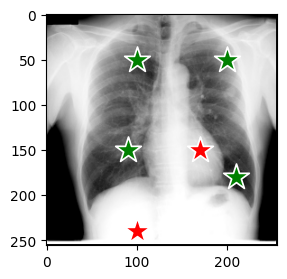

In [19]:
plt.figure(figsize=(3,3))
plt.imshow(example_img)
show_points(input_points, input_label, plt.gca()) # You may also use other prompt methods!
plt.axis('on')
plt.show()

In [21]:
predictor.set_image(example_img)

masks, scores, logits = predictor.predict(
    point_coords=input_points,
    point_labels=input_label,
    multimask_output=True,
)

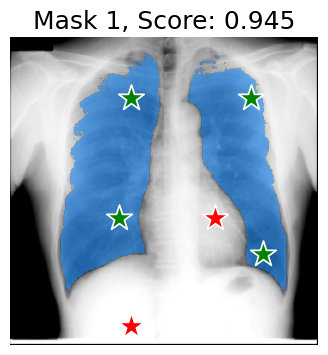

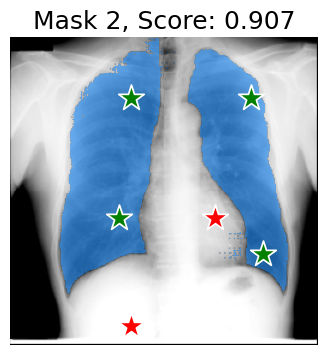

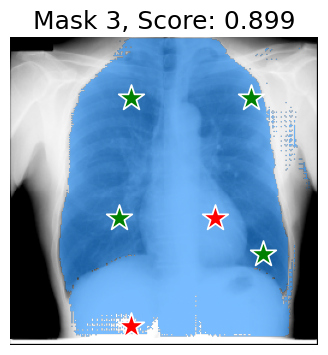

In [22]:
# Note that the "score" here is an estimation of the mask quality, not the quality of the segmentation compared to the ground truth.
for i, (mask, score) in enumerate(zip(masks, scores)):
    plt.figure(figsize=(4,4))
    plt.imshow(example_img.squeeze())
    show_mask(mask, plt.gca())
    show_points(input_points, input_label, plt.gca())
    plt.title(f"Mask {i+1}, Score: {score:.3f}", fontsize=18)
    plt.axis('off')
    plt.show()

# Evaluation loop

In [23]:

f1 = torchmetrics.F1Score(task="binary")

f1_scores = []

for img, mask_gt in zip(x_val, y_val):
    # raise NotImplementedError("TODO: Predict segmentation with SAM and compute F1 score.")
    # YOUR CODE HERE
    predictor.set_image(img)
    mask_pred,scores,logits= predictor.predict(
        point_coords=input_points,
        point_labels=input_label,
        multimask_output=True)
    y_true = torch.from_numpy(mask_gt)
    for mask in mask_pred:
        y_pred = torch.from_numpy(mask)
        f1_score = f1(y_pred, y_true)
        f1_scores.append(f1_score.item())
    
    
mean_f1 = np.mean(f1_scores) # TODO: Compute mean F1 score
std_f1 = np.std(f1_scores) # TODO: Compute standard deviation of F1 scores

print(f"Mean F1 score: {mean_f1:.4f}")
print(f"Standard deviation: {std_f1:.4f}")

Mean F1 score: 0.6719
Standard deviation: 0.2246


In [24]:
def compute_f1_score(predictor, x_val, y_val, input_points, input_label):

    # Initialize F1 score metric
    f1 = torchmetrics.F1Score(task="binary")

    # List to hold F1 scores
    f1_scores = []

    # Set the image for prediction
    predictor.set_image(x_val)
    
    # Predict segmentation with SAM
    mask_pred, scores, logits = predictor.predict(
        point_coords=input_points,
        point_labels=input_label,
        multimask_output=True
    )
    
    # Convert ground truth mask to torch tensor
    y_true = torch.from_numpy(y_val)
    
    # Compute F1 score for each predicted mask
    for mask in mask_pred:
        y_pred = torch.from_numpy(mask)
        f1_score = f1(y_pred, y_true)
        f1_scores.append(f1_score.item())
   
    
    return f1_scores, scores, mask_pred

In [25]:
f1_score1, scores1, mask_pred1 = compute_f1_score(predictor,x_val[9],y_val[9],input_points,input_label)
f1_score2, scores2, mask_pred2 = compute_f1_score(predictor,x_val[2],y_val[2],input_points,input_label)

In [26]:
def plot_masks_with_scores(img, input_points, input_label, masks, scores, f1_scores):
    """
    Plots the predicted masks with their corresponding scores and F1 scores.
    
    Parameters:
    - img: The input image
    - input_points: Input points for the SAM model
    - input_label: Input labels for the SAM model
    - masks: List of predicted masks
    - scores: List of scores for each predicted mask
    - f1_scores: List of F1 scores for each predicted mask
    """
    for i, (mask, score, f1_score) in enumerate(zip(masks, scores, f1_scores)):
        plt.figure(figsize=(4, 4))
        plt.imshow(img.squeeze())
        show_mask(mask, plt.gca())
        show_points(input_points, input_label, plt.gca())
        plt.title(f"Mask {i+1}, Score: {score:.3f}, F1 Score: {f1_score:.3f}", fontsize=18)
        plt.axis('off')
        plt.show()

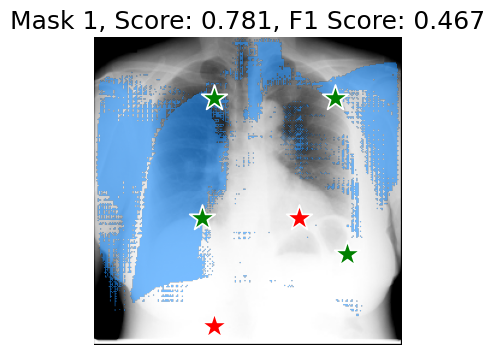

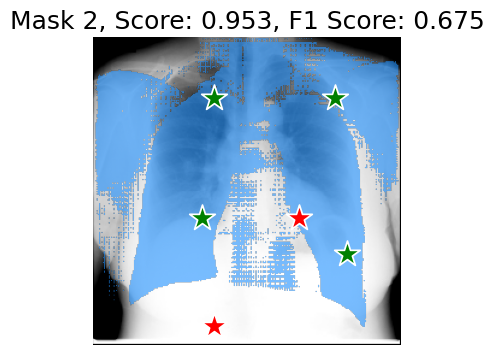

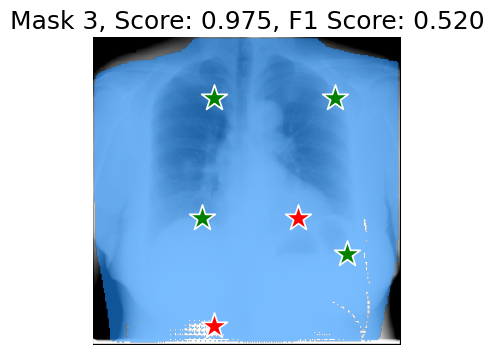

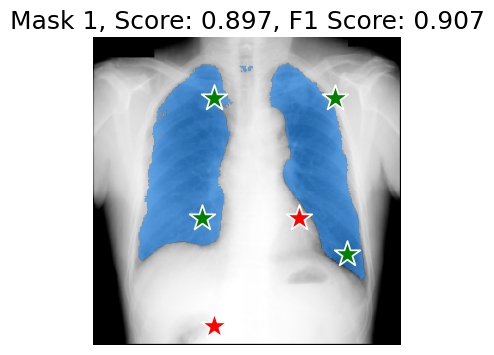

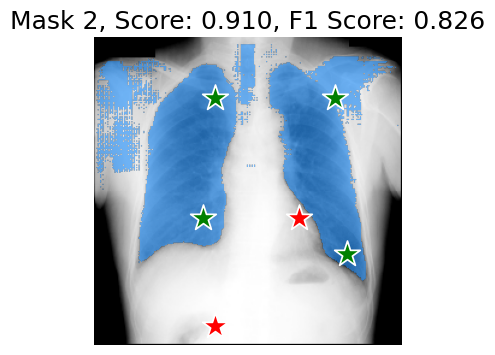

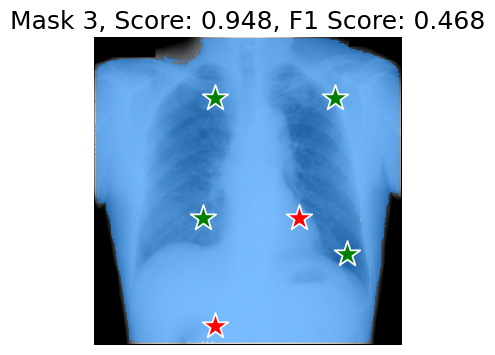

In [27]:
# Plot the results for the first example image
plot_masks_with_scores(x_val[0], input_points, input_label, mask_pred1, scores1, f1_score1)

# Plot the results for the second example image
plot_masks_with_scores(x_val[2], input_points, input_label, mask_pred2, scores2, f1_score2)

# Using Bounding Boxes from GT segmentations as Prompt

In [112]:
# bounding boxes from segmentation masks
# bonding box format [x0, y0, x1, y1]

# TODO: Implement bounding box extraction from segmentation masks

example_img, example_mask = x_train[0], y_train[0]

bbox_prompt =torch.tensor([[40,10,120,220],[140,10,230,220]],device=device) # TODO: Pick apropriate box  


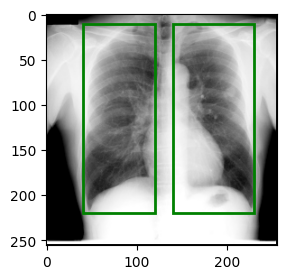

In [113]:
plt.figure(figsize=(3,3))
plt.imshow(example_img)
show_box(bbox_prompt[0].cpu().numpy(), plt.gca()) # You may also use other prompt methods!
show_box(bbox_prompt[1].cpu().numpy(), plt.gca())
plt.axis('on')
plt.show()

In [114]:

## MODIFICATION ON BOUNDING BOX--- example image only take height and width
transformed_boxes = predictor.transform.apply_boxes_torch(bbox_prompt, example_img.shape[:2])


In [115]:
predictor.set_image(example_img)
# mask prediction
masks, scores, _ = predictor.predict_torch(
    point_coords=None,
    point_labels=None,
    boxes=transformed_boxes,
    multimask_output=False,
)

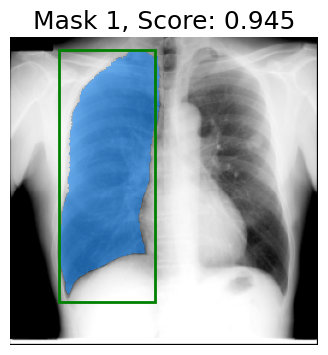

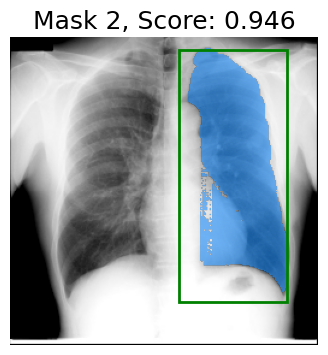

In [116]:
# Note that the "score" here is an estimation of the mask quality, not the quality of the segmentation compared to the ground truth.
#Show two results separately
for i, (mask, score) in enumerate(zip(masks, scores)):
    plt.figure(figsize=(4,4))
    plt.imshow(example_img.squeeze())
    show_mask(mask.cpu().numpy(), plt.gca())
    show_box(bbox_prompt[i].cpu().numpy(), plt.gca())
    plt.title(f"Mask {i+1}, Score: {score.cpu().numpy()[0]:.3f}", fontsize=18)
    plt.axis('off')
    plt.show()

In [117]:
## add left box and right box
overall_mask = masks[0] + masks[1]

tensor([[[False, False, False,  ..., False, False, False],
         [False, False, False,  ..., False, False, False],
         [False, False, False,  ..., False, False, False],
         ...,
         [False, False, False,  ..., False, False, False],
         [False, False, False,  ..., False, False, False],
         [False, False, False,  ..., False, False, False]]], device='cuda:0')

In [119]:
##Calculate f1 score 
f1 = torchmetrics.F1Score(task="binary").to(device)
y_true = torch.from_numpy(example_mask).to(device)
y_pred = overall_mask[0].to(device)
f1_score = f1(y_pred, y_true)


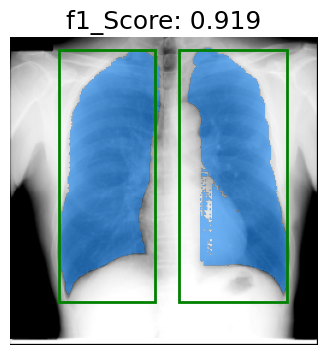

In [120]:

##Show two mask on one graph 
plt.figure(figsize=(4,4))
plt.imshow(example_img.squeeze())
ax = plt.gca()
show_mask(overall_mask.cpu().numpy(), plt.gca())
show_box(bbox_prompt[0].cpu().numpy(), plt.gca())
show_box(bbox_prompt[1].cpu().numpy(), plt.gca())
plt.title(f"f1_Score: {f1_score.cpu().numpy():.3f}", fontsize=18)
plt.axis('off')
plt.show()


In [ ]:
def compute_f1_score(predictor, x_val, y_val, input_points, input_label):

    # Initialize F1 score metric
    f1 = torchmetrics.F1Score(task="binary")

    # List to hold F1 scores
    f1_scores = []

    # Set the image for prediction
    predictor.set_image(x_val)
    
    # Predict segmentation with SAM
    mask_pred, scores, logits = predictor.predict(
        point_coords=input_points,
        point_labels=input_label,
        multimask_output=True
    )
    
    # Convert ground truth mask to torch tensor
    y_true = torch.from_numpy(y_val)
    
    # Compute F1 score for each predicted mask
    for mask in mask_pred:
        y_pred = torch.from_numpy(mask)
        f1_score = f1(y_pred, y_true)
        f1_scores.append(f1_score.item())
   
    
    return f1_scores, scores, mask_pred

# Object Detection Model to predict Bounding Boxes
#### We are going to implement YOLOv11 Or maybe we could fine-tune the model

In [28]:
# TODO: Implement an object detection model to find the left and right lung bounding boxes
from ultralytics import YOLO
import cv2
import numpy as np
import random
example_img, example_mask = x_train[1], y_train[1]


In [29]:
yolo_model = YOLO('yolo11n.pt') 

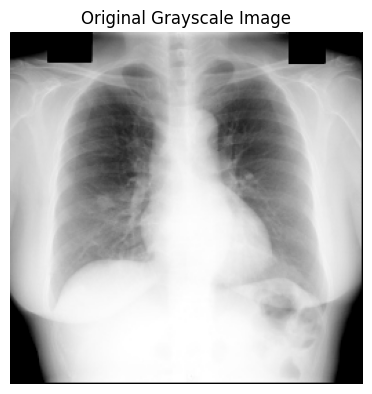

In [30]:
# Display the original grayscale image
plt.figure(figsize=(10, 5))
plt.subplot(1, 2, 1)
plt.imshow(example_img, cmap='gray')
plt.title('Original Grayscale Image')
plt.axis('off')

# Display the equalized image
# plt.subplot(1, 2, 2)
# plt.imshow(equalized_img_bgr, cmap='gray')
# plt.title('Equalized Image')
# plt.axis('off')

plt.show()

In [31]:

# if you want all classes
yolo_classes = list(yolo_model.names.values())
classes_ids = [yolo_classes.index(clas) for clas in yolo_classes]
conf = 0.2
results = yolo_model.predict(example_img, conf=conf)
colors = [random.choices(range(256), k=3) for _ in classes_ids]
print(results)
# for result in results:
#     for mask, box in zip(result.masks.xy, result.boxes):
#         points = np.int32([mask])
#         color_number = classes_ids.index(int(box.cls[0]))
#         cv2.fillPoly(img, points, colors[color_number])



0: 640x640 1 cat, 1 bed, 59.1ms
Speed: 5.8ms preprocess, 59.1ms inference, 3.8ms postprocess per image at shape (1, 3, 640, 640)
[ultralytics.engine.results.Results object with attributes:

boxes: ultralytics.engine.results.Boxes object
keypoints: None
masks: None
names: {0: 'person', 1: 'bicycle', 2: 'car', 3: 'motorcycle', 4: 'airplane', 5: 'bus', 6: 'train', 7: 'truck', 8: 'boat', 9: 'traffic light', 10: 'fire hydrant', 11: 'stop sign', 12: 'parking meter', 13: 'bench', 14: 'bird', 15: 'cat', 16: 'dog', 17: 'horse', 18: 'sheep', 19: 'cow', 20: 'elephant', 21: 'bear', 22: 'zebra', 23: 'giraffe', 24: 'backpack', 25: 'umbrella', 26: 'handbag', 27: 'tie', 28: 'suitcase', 29: 'frisbee', 30: 'skis', 31: 'snowboard', 32: 'sports ball', 33: 'kite', 34: 'baseball bat', 35: 'baseball glove', 36: 'skateboard', 37: 'surfboard', 38: 'tennis racket', 39: 'bottle', 40: 'wine glass', 41: 'cup', 42: 'fork', 43: 'knife', 44: 'spoon', 45: 'bowl', 46: 'banana', 47: 'apple', 48: 'sandwich', 49: 'orange

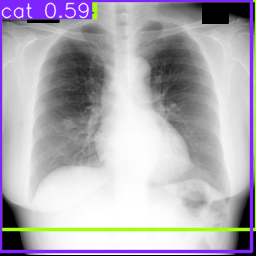

In [32]:
# 绘制检测结果
for result in results:
    annotated_image = result.plot()  # 返回一个包含标注的图像的NumPy数组
    # 显示图像
    result.show()
    # 如果需要保存图像，可以使用以下代码
    # result.save(filename="annotated_image.jpg")

#### Try using faster CNN models

In [6]:
import torch
import torchvision
from torchvision.models.detection import fasterrcnn_resnet50_fpn
from torchvision.transforms import functional as F
import matplotlib.pyplot as plt
import numpy as np

In [18]:
# Specify the path to the downloaded weights
weights_path = '/mnt/f/Assignment_3/datasets/fasterrcnn_resnet50_fpn_coco-258fb6c6.pth'

# Load the model without pretrained weights
model = fasterrcnn_resnet50_fpn(pretrained=False)

# Load the pre-trained weights from the specified path
model.load_state_dict(torch.load(weights_path))

model.eval()

/home/pkd916/miniconda3/envs/assignment3/lib/python3.12/site-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/home/pkd916/miniconda3/envs/assignment3/lib/python3.12/site-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=None`.
  warnings.warn(msg)
/tmp/ipykernel_362345/1381077885.py:8: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `we

FasterRCNN(
  (transform): GeneralizedRCNNTransform(
      Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
      Resize(min_size=(800,), max_size=1333, mode='bilinear')
  )
  (backbone): BackboneWithFPN(
    (body): IntermediateLayerGetter(
      (conv1): Conv2d(3, 64, kernel_size=(7, 7), stride=(2, 2), padding=(3, 3), bias=False)
      (bn1): FrozenBatchNorm2d(64, eps=1e-05)
      (relu): ReLU(inplace=True)
      (maxpool): MaxPool2d(kernel_size=3, stride=2, padding=1, dilation=1, ceil_mode=False)
      (layer1): Sequential(
        (0): Bottleneck(
          (conv1): Conv2d(64, 64, kernel_size=(1, 1), stride=(1, 1), bias=False)
          (bn1): FrozenBatchNorm2d(64, eps=1e-05)
          (conv2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
          (bn2): FrozenBatchNorm2d(64, eps=1e-05)
          (conv3): Conv2d(64, 256, kernel_size=(1, 1), stride=(1, 1), bias=False)
          (bn3): FrozenBatchNorm2d(256, eps=1e-05)
          (relu

In [73]:
example_img, example_mask = x_train[11], y_train[11]

# Preprocess the image
img_tensor = F.to_tensor(example_img)  # Convert the image to a tensor

In [74]:
# Perform object detection
with torch.no_grad():
    predictions = model([img_tensor])

# Extract the bounding boxes, labels, and scores
boxes = predictions[0]['boxes'].cpu().numpy()
labels = predictions[0]['labels'].cpu().numpy()
scores = predictions[0]['scores'].cpu().numpy()

# # Set a confidence threshold to filter out low-confidence detections
# confidence_threshold = 0.5
# filtered_boxes = boxes[scores >= confidence_threshold]
# filtered_labels = labels[scores >= confidence_threshold]
# filtered_scores = scores[scores >= confidence_threshold]




In [78]:
labels,scores

(array([17, 17,  1,  1, 17, 17,  1, 65,  1, 37,  1, 63, 65]),
 array([0.8639394 , 0.75310206, 0.5636331 , 0.558756  , 0.30411395,
        0.29900762, 0.11203068, 0.10816132, 0.09727162, 0.07151385,
        0.06821268, 0.05542177, 0.05317342], dtype=float32))

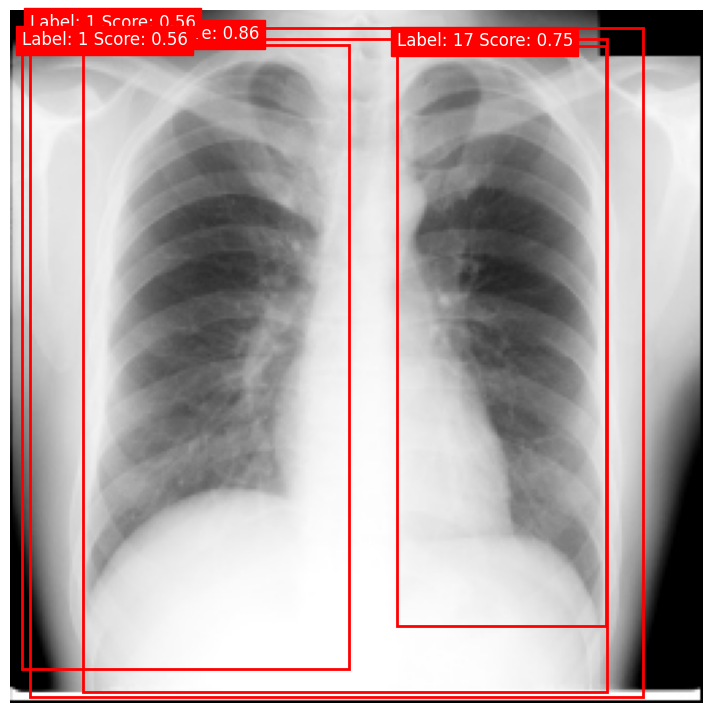

In [77]:
import matplotlib.pyplot as plt
import numpy as np

def plot_image_with_boxes(img, boxes, labels, scores, num_boxes_to_plot=1):
    # Sort the boxes, labels, and scores by scores in descending order
    sorted_indices = np.argsort(scores)[::-1]
    boxes = boxes[sorted_indices]
    labels = labels[sorted_indices]
    scores = scores[sorted_indices]

    fig, ax = plt.subplots(1, figsize=(12, 9))
    ax.imshow(img)

    # Plot the specified number of boxes
    for i in range(min(num_boxes_to_plot, len(boxes))):
        x_min, y_min, x_max, y_max = boxes[i]
        rect = plt.Rectangle((x_min, y_min), x_max - x_min, y_max - y_min, fill=False, color='red', linewidth=2)
        ax.add_patch(rect)
        ax.text(x_min, y_min, f'Label: {labels[i]} Score: {scores[i]:.2f}', color='white', fontsize=12, backgroundcolor='red')

    plt.axis('off')
    plt.show()

# Plot the image with a specified number of bounding boxes
plot_image_with_boxes(np.array(example_img), boxes, labels, scores, num_boxes_to_plot=4)

#### Try mask RNN

/home/pkd916/miniconda3/envs/assignment3/lib/python3.12/site-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/home/pkd916/miniconda3/envs/assignment3/lib/python3.12/site-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=None`.
  warnings.warn(msg)
/tmp/ipykernel_362345/270887764.py:17: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `we

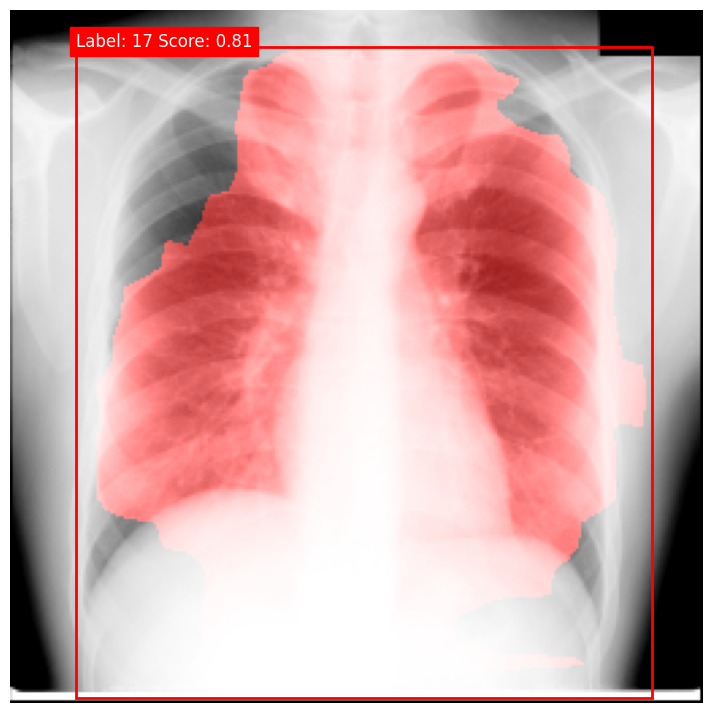

In [82]:
import torch
import torchvision
from torchvision.models.detection import maskrcnn_resnet50_fpn
from torchvision.transforms import functional as F
import matplotlib.pyplot as plt
import numpy as np
import cv2

# Load a pre-trained Mask R-CNN model
# Specify the path to the downloaded weights
weights_path = '/mnt/f/Assignment_3/datasets/maskrcnn_resnet50_fpn_coco-bf2d0c1e.pth'

# Load the model without pretrained weights
model = maskrcnn_resnet50_fpn(pretrained=False)

# Load the pre-trained weights from the specified path
model.load_state_dict(torch.load(weights_path))

model.eval() # Set the model to evaluation mode

example_img, example_mask = x_train[11], y_train[11]

# Preprocess the image
img_tensor = F.to_tensor(example_img)  # Convert the image to a tensor
# Perform object detection
with torch.no_grad():
    predictions = model([img_tensor])

# Extract the bounding boxes, labels, scores, and masks
boxes = predictions[0]['boxes'].cpu().numpy()
labels = predictions[0]['labels'].cpu().numpy()
scores = predictions[0]['scores'].cpu().numpy()
masks = predictions[0]['masks'].cpu().numpy()

# Set a confidence threshold to filter out low-confidence detections
confidence_threshold = 0.5
filtered_boxes = boxes[scores >= confidence_threshold]
filtered_labels = labels[scores >= confidence_threshold]
filtered_scores = scores[scores >= confidence_threshold]
filtered_masks = masks[scores >= confidence_threshold]

# Function to plot image with bounding boxes and masks
def plot_image_with_boxes_and_masks(img, boxes, labels, scores, masks, threshold=0.5):
    fig, ax = plt.subplots(1, figsize=(12, 9))
    ax.imshow(img)

    for i in range(len(boxes)):
        if scores[i] >= threshold:
            x_min, y_min, x_max, y_max = boxes[i]
            rect = plt.Rectangle((x_min, y_min), x_max - x_min, y_max - y_min, fill=False, color='red', linewidth=2)
            ax.add_patch(rect)
            ax.text(x_min, y_min, f'Label: {labels[i]} Score: {scores[i]:.2f}', color='white', fontsize=12, backgroundcolor='red')

            # Apply mask
            mask = masks[i, 0]
            color_mask = np.zeros_like(img)
            color_mask[mask > 0.5] = [255, 0, 0]  # Red color for the mask
            img_with_mask = cv2.addWeighted(np.array(img), 1.0, color_mask, 0.5, 0)
            ax.imshow(img_with_mask)

    plt.axis('off')
    plt.show()

# Plot the image with bounding boxes and masks
plot_image_with_boxes_and_masks(np.array(example_img), filtered_boxes, filtered_labels, filtered_scores, filtered_masks, confidence_threshold)